In [1]:
import torch
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

print("cwd =", os.getcwd())

from solvers.torch_eit_fem_solver import EIT
from solvers.torch_eit_fem_solver.fem import Mesh, V_h, dtn_map
from solvers.torch_eit_fem_solver.utils import dtn_from_sigma
from torchdiffeq import odeint, odeint_adjoint
import matplotlib.pyplot as plt
import cmocean as cmo
from scipy import io as sio
from tqdm import tqdm
from models.JiT import JiTUncond_B_8, JiT_XS_8
from models.triangular import TriangularFineTune
from collections import OrderedDict
import numpy as np

torch.manual_seed(159753)
np.random.seed(159753)

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn

device = 'cuda:1' 


cwd = /home/johnma/flow-inverse


/home/johnma/flow-inverse/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
import random 
# load mesh
data_root = 'mesh-data'
mesh_file = 'mesh_128_h05.mat'
img_size = 128
original_size = 128
pad_size = 0


mat_fname  = os.path.join(data_root, mesh_file)
mat_contents = sio.loadmat(mat_fname)

p = torch.tensor(mat_contents['p'], dtype=torch.float64).to(device)
t = torch.tensor(mat_contents['t']-1, dtype=torch.long).to(device)
vol_idx = torch.tensor(mat_contents['vol_idx'].reshape((-1,))-1, dtype=torch.long).to(device)
bdy_idx = torch.tensor(mat_contents['bdy_idx'].reshape((-1,))-1, dtype=torch.long).to(device)

mesh = Mesh(p, t, bdy_idx, vol_idx)
v_h = V_h(mesh)

# get the dtn map
dtn_background = dtn_from_sigma(sigma_vec=torch.ones(128, 128), v_h=v_h, mesh=mesh, img_size=128, device=device)
# dtn_map = torch.log(dtn_map)

dataset = torch.load(f"data/eit-circles-dtn-default-128.pt", map_location="cpu")

dataset_X_train = dataset["train"]["dtn_map"]
dtn_background_device = dtn_background.to(dataset_X_train.device)
dataset_X_train /= dtn_background_device
dataset_Y_train = dataset["train"]["media"]

dataset_X_train = dataset_X_train.float()
dataset_Y_train = dataset_Y_train.float()

train_X_min = dataset_X_train.min()
train_X_max = dataset_X_train.max()
train_Y_min = dataset_Y_train.min()
train_Y_max = dataset_Y_train.max()


In [3]:
y_model = JiTUncond_B_8(in_channels=1, input_size=128).to(device)
theta_model = JiT_XS_8(in_channels=1, cond_in_channels=1, out_channels=1, input_size=128).to(device)
# if you are resuming training from a checkpoint for fine tuning itself you should just load the original weights again here, then we load new weights later
# this is just because i wrote the constructor to need weights to load
model = TriangularFineTune(
    y_net=y_model,
    y_net_ckpt="saved_runs/circles-eit-x-pred-dtn-JiT/checkpoints/ckp_100125.tar",
    theta_net=theta_model,
    theta_net_ckpt="saved_runs/circles-eit-cond-dtn-strong-JiT-ema-nocfg/checkpoints/best.tar",
).to(device)
model.eval()
x0 = torch.randn(1, 2, 128, 128).to(device)

SIGMA_MIN = 1e-2
EPS = 5e-2
class VField(torch.nn.Module):
    def __init__(self, model):
        super(VField, self).__init__()
        self.model = model
    def forward(self, t, z):
        t_batch = t.expand(z.shape[0])
        t_broadcast = t_batch[:, None, None, None]
        with torch.autocast(device_type=z.device.type, dtype=torch.bfloat16):
            x_pred = self.model(z, t_batch)
        sigma = torch.clamp(1 - (1 - SIGMA_MIN) * t_broadcast, min=EPS)
        return x_pred - (1 - SIGMA_MIN) * (z - t_broadcast * x_pred) / sigma

v_field = VField(model)

In [4]:
timesteps = torch.linspace(0.0, 1.0, steps=28).to(device)
with torch.amp.autocast(device_type=device, dtype=torch.bfloat16):
    with torch.no_grad():
        pred = odeint(
            func=v_field,
            t=timesteps,
            y0=x0,
            method='fehlberg2',
            atol=1e-4,
            rtol=1e-4,
        )[-1]

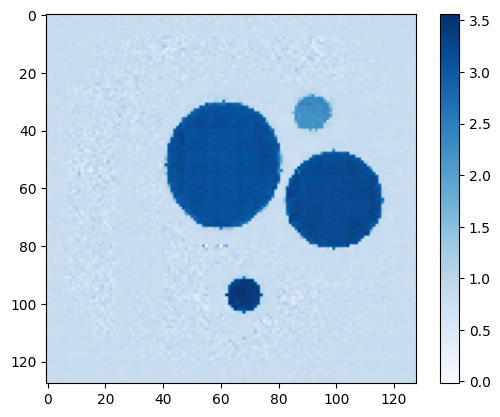

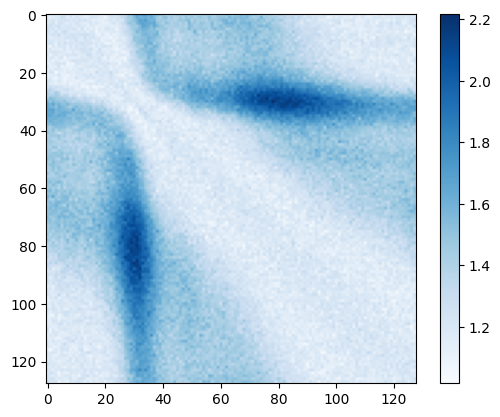

tensor(-0.0173, device='cuda:1')
tensor(3.5645, device='cuda:1')
tensor(1.0177, device='cuda:1')
tensor(2.2173, device='cuda:1')


In [5]:
# plot pred (2 channels)
y  = pred[:, 0]
theta = pred[:, 1]

# unnormalize
#  dataset_X_train = 2.0 * (dataset_X_train - train_X_min) / (train_X_max - train_X_min + 1e-12) - 1.0
#  dataset_Y_train = 2.0 * (dataset_Y_train - train_Y_min) / (train_Y_max - train_Y_min + 1e-12) - 1.0

theta = (theta + 1.0) / 2.0 * (train_X_max- train_X_min) + train_X_min
y = (y + 1.0) / 2.0 * (train_Y_max- train_Y_min) + train_Y_min

import matplotlib.pyplot as plt
plt.imshow(theta.cpu().numpy().squeeze(), cmap='Blues')
plt.colorbar()
plt.show()

plt.imshow(y.cpu().numpy().squeeze(), cmap='Blues')
plt.colorbar()
plt.show()

print(theta.min())
print(theta.max())
print(y.min())
print(y.max())


In [6]:
theta_model_state = torch.load("saved_runs/circles-eit-cond-dtn-strong-JiT-ema-nocfg/checkpoints/best.tar", map_location=device)
ema_theta = AveragedModel(theta_model, multi_avg_fn=get_ema_multi_avg_fn(0.999))
ema_theta.load_state_dict(theta_model_state["ema_state_dict"])  # handles n_averaged + module.* keys
theta_model.load_state_dict(ema_theta.module.state_dict())     

<All keys matched successfully>

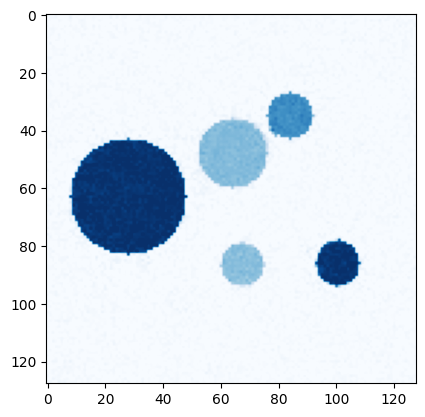

In [ ]:
# baseline
theta_model.eval()
def v_field_cond(z, t, x_cond):
    t_batch = t.expand(z.shape[0])
    v_cond = theta_model(z, t_batch, x_cond)
    return v_cond 

timesteps = torch.linspace(0.0, 1.0, steps=20).to(device)
z0 = torch.randn(1, 1, 128, 128, device=device)
cond = dataset["test"]["dtn_map"][0].to(device)
cond /= dtn_background_device.to(device)
cond = 2.0 * (cond - train_X_min) / (train_X_max - train_X_min + 1e-12) - 1.0
cond = cond.unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    pred  = odeint(
        func=lambda t, x: v_field_cond(x, t, cond),
        t=timesteps,
        y0=z0,
        method='heun3',
        atol=1e-5,
        rtol=1e-5,
    )[-1]
# unnormalize
pred = 0.5 * (pred + 1.0) * (train_Y_max - train_Y_min) + train_Y_min
plt.imshow(pred.squeeze().detach().cpu().numpy(), cmap="Blues", vmin=1, vmax=5)
plt.show()

In [11]:
import torch
from torch import nn
from torch import optim
from torch.nn import MSELoss, HuberLoss
import time

lr = 1e-3
optim_steps = 1000
lbfgs_max_iter = 20
lbfgs_history_size = 10

loss_fn = MSELoss()
support_loss = MSELoss()
x1_y_trajectory = []
x1_theta_trajectory = []
lamb_reg = 1e-4

x0 = torch.randn((1, 2, 128, 128), device=device, dtype=torch.float32, requires_grad=True)

gt_y = dataset["test"]["dtn_map"][0].squeeze().to(device)
gt_y /= dtn_background_device.to(device)
gt_theta = dataset["test"]["media"][0].squeeze().to(device)

pred_theta = pred

# optimizer = optim.LBFGS([x0], max_iter=lbfgs_max_iter, lr=lr,
                        # history_size=lbfgs_history_size, line_search_fn='strong_wolfe')
optimizer = optim.Adam([x0], lr=lr, betas=(0.9, 0.99))
# optimizer = optim.SGD([x0], lr=lr)

cache = {'x1_y': None, 'x1_theta': None, 'loss': None}
last_loss = None
start_time = time.time()
pbar = tqdm(range(optim_steps), desc="D-Flow")

timesteps = torch.linspace(0, 1, 16, device=device)

for step in pbar:
    def closure():
        optimizer.zero_grad()

        # amp autocast
        with torch.amp.autocast(device_type=device, dtype=torch.bfloat16):
            x1 = odeint(
                func=v_field,
                t=timesteps,
                y0=x0,
                method='midpoint'
            )[-1]

        x1_theta = x1[:, 1, :, :]
        x1_y = x1[:, 0, :, :]

        # unnormalize x1
        x1_theta = 0.5 * (x1_theta + 1.0) * (train_X_max - train_X_min) + train_X_min
        x1_y = 0.5 * (x1_y + 1.0) * (train_Y_max - train_Y_min) + train_Y_min

        loss = loss_fn(gt_y, x1_y.squeeze()) + lamb_reg * x0.norm() # stays on manifold
        # loss += support_loss(pred_theta.squeeze(), x1_theta.squeeze()) # cond model usually gets support correct
        loss.backward()

        cache['x1_y'] = x1_y.detach()
        cache['x1_theta'] = x1_theta.detach()
        cache['loss'] = loss.detach()

        return loss

    optimizer.step(closure)

    x1_y_trajectory.append(cache['x1_y'].cpu().numpy())
    last_loss = cache['loss'].item()
    x1_theta_trajectory.append(cache['x1_theta'].cpu().numpy())

    grad_norm = x0.grad.norm().item()
    pbar.set_postfix({
        'loss': f'{last_loss:.4f}',
        'grad_norm': f'{grad_norm:.4f}',
    })

print(f"Optimization completed in {time.time() - start_time:.1f} seconds")

D-Flow:  22%|██▏       | 220/1000 [03:44<13:14,  1.02s/it, loss=0.0456, grad_norm=0.0015]


KeyboardInterrupt: 

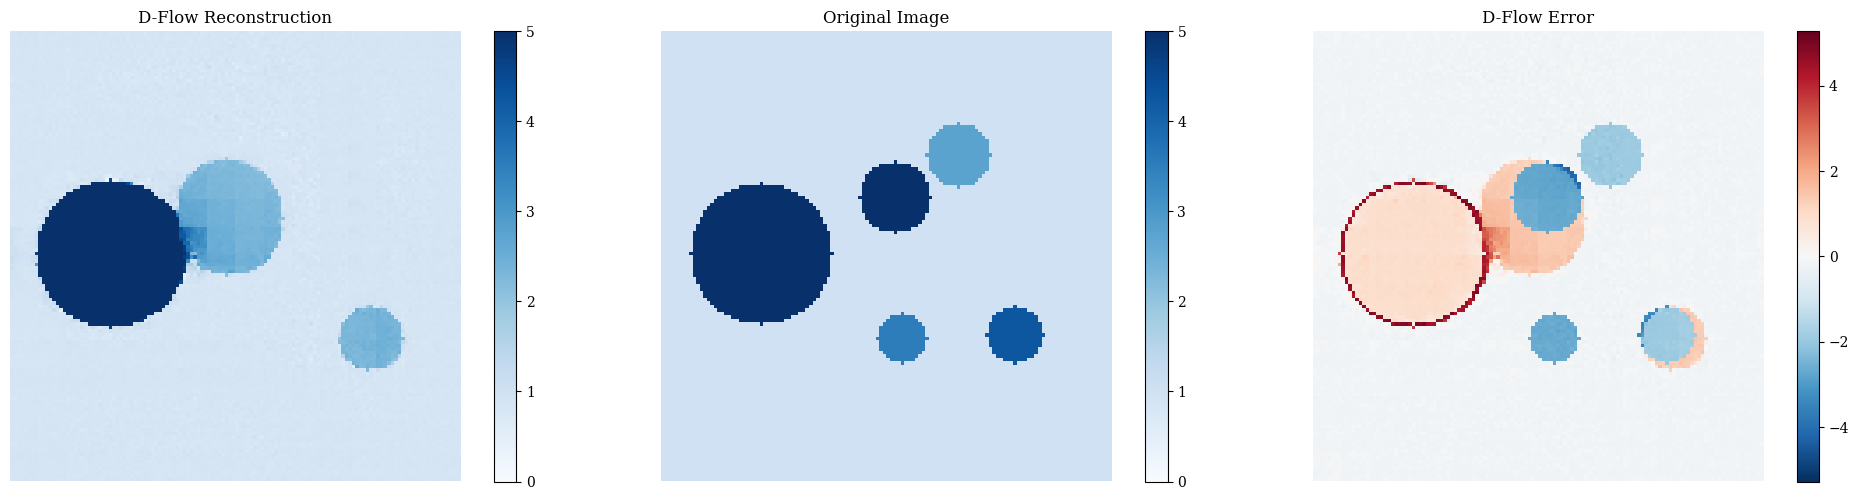

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

baseline = pred

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.seterr(divide='ignore', invalid='ignore')
plt.rcParams["font.family"] = "DejaVu Serif"
title_font = {"family": "DejaVu Serif", "weight": "bold", "size": 12}
fig, axes = plt.subplots(1, 3, figsize=(20, 5))


im1 = axes[0].imshow(baseline.squeeze().detach().cpu().numpy(), cmap="Blues", vmin=0, vmax=5)
axes[0].set_title('D-Flow Reconstruction')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im3 = axes[1].imshow(gt_theta.squeeze().cpu().numpy(), cmap="Blues", vmin=0, vmax=5)
axes[1].set_title('Original Image')
axes[1].axis('off')
plt.colorbar(im3, ax=axes[1])

error = baseline.squeeze().detach().cpu().numpy() - gt_theta.squeeze().cpu().numpy()
im4 = axes[2].imshow(error, cmap='RdBu_r', vmin=-np.abs(error).max(), vmax=np.abs(error).max())
axes[2].set_title('D-Flow Error')
axes[2].axis('off')
plt.colorbar(im4, ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

# use higher order integrator to get final x1
with torch.no_grad():
    x1_final = odeint(
                func=v_field,
                t=timesteps,
                y0=x0,
                method='fehlberg2',
                atol=1e-5,
                rtol=1e-5,
            )[-1]

x1_theta = x1_final[:, 1, :, :]
x1_theta = 0.5 * (x1_theta + 1.0) * (train_X_max - train_X_min) + train_X_min

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.seterr(divide='ignore', invalid='ignore')
plt.rcParams["font.family"] = "DejaVu Serif"
title_font = {"family": "DejaVu Serif", "weight": "bold", "size": 12}
fig, axes = plt.subplots(1, 3, figsize=(20, 5))


im1 = axes[0].imshow(x1_theta.squeeze().detach().cpu().numpy(), cmap="Blues", vmin=0, vmax=5)
axes[0].set_title('D-Flow Reconstruction')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im3 = axes[1].imshow(gt_theta.squeeze().cpu().numpy(), cmap="Blues", vmin=0, vmax=5)
axes[1].set_title('Original Image')
axes[1].axis('off')
plt.colorbar(im3, ax=axes[1])

error = x1_theta.squeeze().detach().cpu().numpy() - gt_theta.squeeze().cpu().numpy()
im4 = axes[2].imshow(error, cmap='RdBu_r', vmin=-np.abs(error).max(), vmax=np.abs(error).max())
axes[2].set_title('D-Flow Error')
axes[2].axis('off')
plt.colorbar(im4, ax=axes[2])

plt.tight_layout()
plt.show()


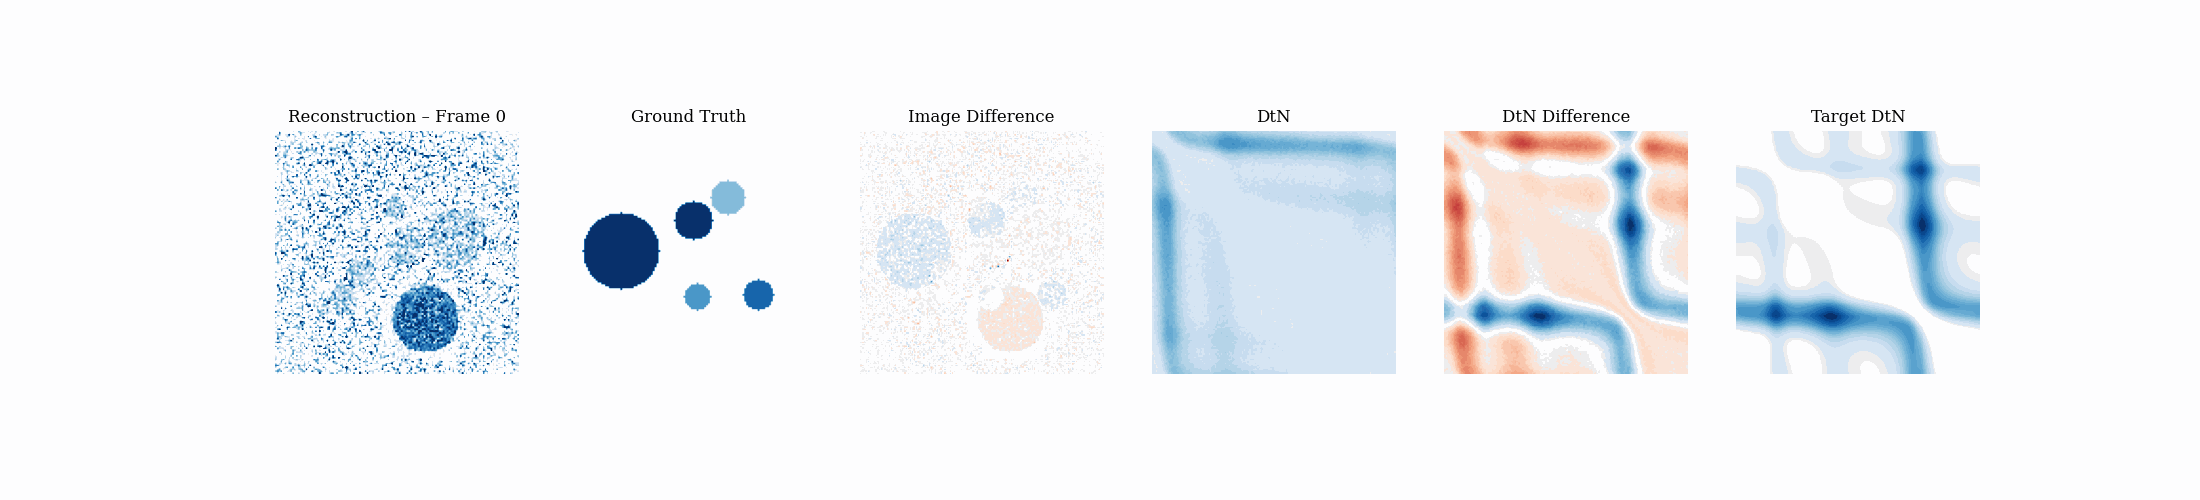

In [ ]:
from matplotlib.animation import PillowWriter
import base64, tempfile

import matplotlib.animation as animation
from IPython.display import HTML

SUBSAMPLE = True
SUBSAMPLE_STRIDE = 1

fig, axes = plt.subplots(1, 6, figsize=(22, 5))
ax1, ax2, ax3, ax4, ax5, ax6 = axes

gt_theta_img = gt_theta.squeeze().cpu().numpy()
gt_y_img = gt_y.squeeze().cpu().numpy()

num_frames = len(x1_theta_trajectory)
if num_frames == 0:
    raise ValueError("No trajectory samples available for animation.")

if SUBSAMPLE:
    frame_indices = list(range(0, num_frames, SUBSAMPLE_STRIDE))
    if frame_indices[-1] != num_frames - 1:
        frame_indices.append(num_frames - 1)
else:
    frame_indices = list(range(num_frames))

def animate_comparison(frame_idx):
    idx = frame_indices[frame_idx]
    for ax in axes:
        ax.clear()

    current_img = x1_theta_trajectory[idx].squeeze()
    current_dtn = x1_y_trajectory[idx].squeeze()

    im1 = ax1.imshow(current_img, cmap="Blues",
                     vmin=1, vmax=5)
    ax1.set_title(f"Reconstruction – Frame {idx}", fontsize=12)
    ax1.axis("off")

    im2 = ax2.imshow(gt_theta_img, cmap="Blues",
                     vmin=1, vmax=5)
    ax2.set_title("Ground Truth", fontsize=12)
    ax2.axis("off")

    diff_img = current_img - gt_theta_img
    diff_lim = np.abs(diff_img).max() + 1e-12
    im3 = ax3.imshow(diff_img, cmap="RdBu_r",
                     vmin=-diff_lim, vmax=diff_lim)
    ax3.set_title("Image Difference", fontsize=12)
    ax3.axis("off")

    im4 = ax4.imshow(current_dtn, cmap="Blues",
                     vmin=gt_y_img.min(), vmax=gt_y_img.max())
    ax4.set_title("DtN", fontsize=12)
    ax4.axis("off")

    dtn_diff = current_dtn - gt_y_img
    dtn_diff_lim = np.abs(dtn_diff).max() + 1e-12
    im5 = ax5.imshow(dtn_diff, cmap="RdBu_r",
                     vmin=-dtn_diff_lim, vmax=dtn_diff_lim)
    ax5.set_title("DtN Difference", fontsize=12)
    ax5.axis("off")

    im6 = ax6.imshow(gt_y_img, cmap="Blues",
                     vmin=gt_y_img.min(), vmax=gt_y_img.max())
    ax6.set_title("Target DtN", fontsize=12)
    ax6.axis("off")

    return [im1, im2, im3, im4, im5, im6]

anim_comparison = animation.FuncAnimation(
    fig, animate_comparison, frames=len(frame_indices),
    interval=300, blit=False, repeat=True
)
writer = PillowWriter(fps=6)
with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp:
    anim_comparison.save(tmp.name, writer=writer)
    tmp.flush()
    tmp.seek(0)
    gif_base64 = base64.b64encode(tmp.read()).decode("ascii")
plt.close(fig)
html_comparison = HTML(
    f'<img src="data:image/gif;base64,{gif_base64}" loop="true">'
)
html_comparison